<a href="https://colab.research.google.com/github/WeedSmoothie/cognitive-aging-analysis/blob/main/R__OASIS_1ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 인지노화 데이터 분석 - OASIS-1
**데이터**: OASIS-1 (416명, 18~96세, 인지점수 + 뇌 구조 지표)  
**목표**: 나이와 뇌 구조가 인지기능에 미치는 영향을 회귀분석으로 탐색

In [1]:
install.packages(c("tidyverse", "psych", "broom", "lme4", "lmerTest"),
                 quiet = TRUE)
library(tidyverse)
library(psych)
library(broom)

also installing the dependencies ‘rbibutils’, ‘mnormt’, ‘GPArotation’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘numDeriv’


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘psych’


The following objects are masked from ‘package:ggplot2’:

    %+%, alpha




In [11]:
library(tidyverse)
library(ggplot2)

df <- read_csv("/content/oasis_cross-sectional.csv")
df <- df %>% rename(Sex = `M/F`)

df_cog <- df %>%
  select(Age, MMSE, nWBV, CDR, Sex, Educ) %>%
  mutate(Sex = as.factor(Sex)) %>%
  drop_na(Age, MMSE, nWBV)

cat("분석 샘플 수:", nrow(df_cog), "\n")
summary(df_cog)

Rows: 436 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): ID, M/F, Hand, Delay
dbl (8): Age, Educ, SES, MMSE, CDR, eTIV, nWBV, ASF

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


분석 샘플 수: 235 


      Age             MMSE            nWBV             CDR         Sex    
 Min.   :33.00   Min.   :14.00   Min.   :0.6440   Min.   :0.0000   F:156  
 1st Qu.:66.00   1st Qu.:26.00   1st Qu.:0.7135   1st Qu.:0.0000   M: 79  
 Median :73.00   Median :29.00   Median :0.7470   Median :0.0000          
 Mean   :72.34   Mean   :27.06   Mean   :0.7491   Mean   :0.2851          
 3rd Qu.:81.00   3rd Qu.:30.00   3rd Qu.:0.7840   3rd Qu.:0.5000          
 Max.   :96.00   Max.   :30.00   Max.   :0.8470   Max.   :2.0000          
      Educ      
 Min.   :1.000  
 1st Qu.:2.000  
 Median :3.000  
 Mean   :3.179  
 3rd Qu.:4.000  
 Max.   :5.000  

In [12]:
df_cog %>%
  select(Age, MMSE, nWBV, Educ) %>%
  psych::describe() %>%
  round(2)

,vars,n,mean,sd,median,trimmed,mad,min,max,range,skew,kurtosis,se
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age,1,235,72.34,12.09,73.00,73.20,11.86,33.00,96.00,63.0,-0.64,0.02,0.79
MMSE,2,235,27.06,3.70,29.00,27.77,1.48,14.00,30.00,16.0,-1.59,1.85,0.24
nWBV,3,235,0.75,0.05,0.75,0.75,0.05,0.64,0.85,0.2,0.00,-0.84,0.00
Educ,4,235,3.18,1.31,3.00,3.22,1.48,1.00,5.00,4.0,-0.01,-1.24,0.09


In [13]:
cor(df_cog %>% select(Age, MMSE, nWBV, Educ), use = "complete.obs") %>% round(2)

,Age,MMSE,nWBV,Educ
Age,1.00,-0.25,-0.72,-0.21
MMSE,-0.25,1.00,0.47,0.30
nWBV,-0.72,0.47,1.00,0.19
Educ,-0.21,0.30,0.19,1.00


`geom_smooth()` using formula = 'y ~ x'


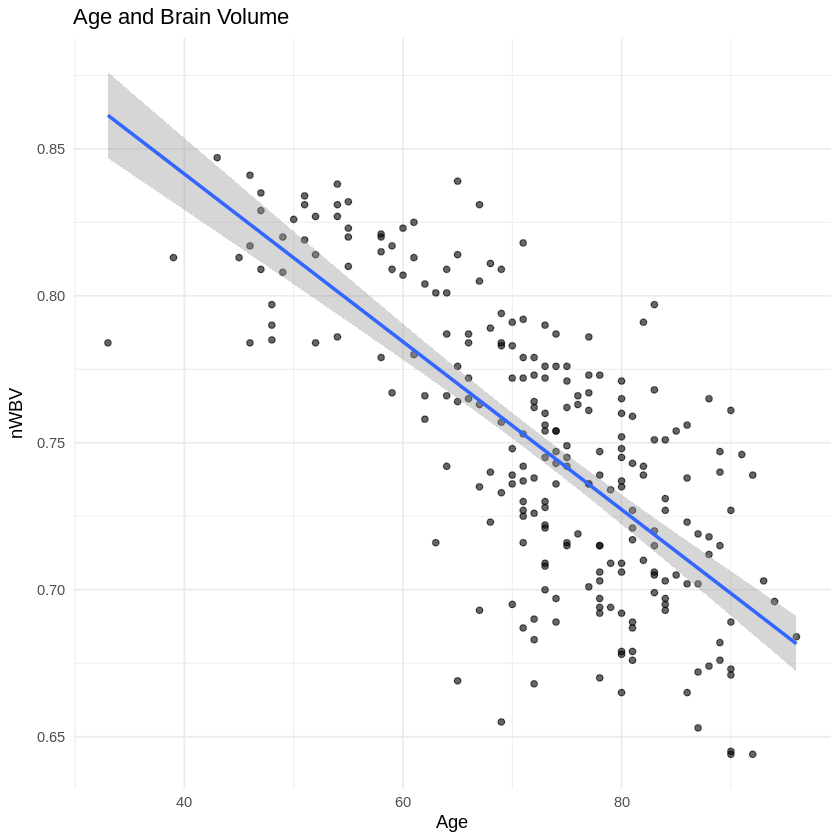

In [14]:
ggplot(df_cog, aes(x = Age, y = nWBV)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(title = "Age and Brain Volume", x = "Age", y = "nWBV") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


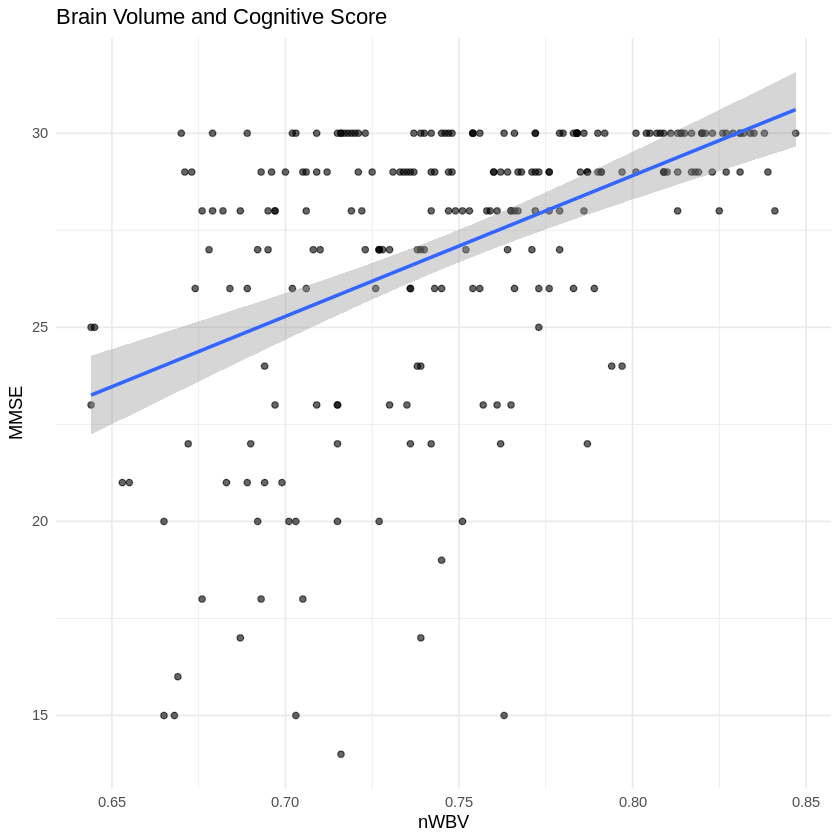

In [15]:
ggplot(df_cog, aes(x = nWBV, y = MMSE)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(title = "Brain Volume and Cognitive Score", x = "nWBV", y = "MMSE") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


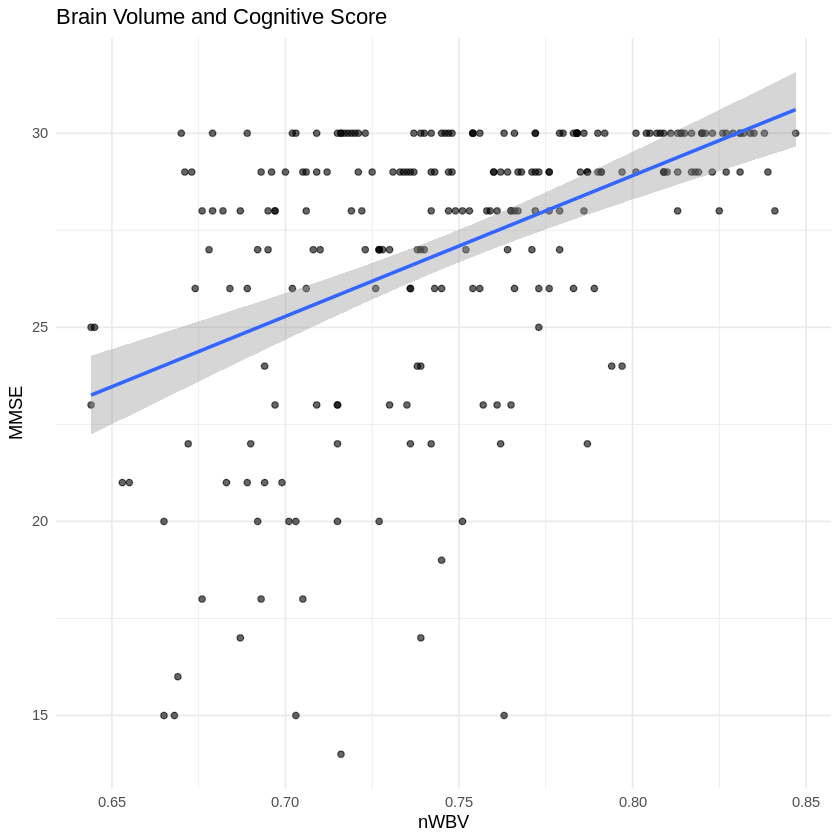

In [16]:
ggplot(df_cog, aes(x = nWBV, y = MMSE)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(title = "Brain Volume and Cognitive Score", x = "nWBV", y = "MMSE") +
  theme_minimal()

In [17]:
model1 <- lm(nWBV ~ Age, data = df_cog)
summary(model1)


Call:
lm(formula = nWBV ~ Age, data = df_cog)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.103678 -0.022919  0.003446  0.025176  0.078278 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.955602   0.013204   72.37   <2e-16 ***
Age         -0.002854   0.000180  -15.85   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.0333 on 233 degrees of freedom
Multiple R-squared:  0.5189,	Adjusted R-squared:  0.5168 
F-statistic: 251.3 on 1 and 233 DF,  p-value: < 2.2e-16


In [18]:
model2 <- lm(MMSE ~ nWBV, data = df_cog)
summary(model2)


Call:
lm(formula = MMSE ~ nWBV, data = df_cog)

Residuals:
     Min       1Q   Median       3Q      Max 
-12.5664  -1.0483   0.5854   2.0678   5.8038 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.08375    3.35050  -0.025     0.98    
nWBV        36.23872    4.46344   8.119 2.72e-14 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.271 on 233 degrees of freedom
Multiple R-squared:  0.2205,	Adjusted R-squared:  0.2172 
F-statistic: 65.92 on 1 and 233 DF,  p-value: 2.722e-14


In [19]:
model3 <- lm(MMSE ~ nWBV + Age, data = df_cog)
summary(model3)


Call:
lm(formula = MMSE ~ nWBV + Age, data = df_cog)

Residuals:
     Min       1Q   Median       3Q      Max 
-12.4118  -1.0966   0.5505   2.1617   6.2819 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -11.50101    6.23548  -1.844   0.0664 .  
nWBV         46.19240    6.38470   7.235 6.75e-12 ***
Age           0.05475    0.02530   2.164   0.0315 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.245 on 232 degrees of freedom
Multiple R-squared:  0.2359,	Adjusted R-squared:  0.2294 
F-statistic: 35.82 on 2 and 232 DF,  p-value: 2.768e-14


In [20]:
model4 <- lm(MMSE ~ nWBV + Age + CDR + Sex + Educ, data = df_cog)
summary(model4)


Call:
lm(formula = MMSE ~ nWBV + Age + CDR + Sex + Educ, data = df_cog)

Residuals:
     Min       1Q   Median       3Q      Max 
-10.5689  -1.0377   0.1841   1.1757   7.0065 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 12.41578    5.10054   2.434  0.01569 *  
nWBV        16.73458    5.26269   3.180  0.00168 ** 
Age          0.03833    0.01898   2.019  0.04467 *  
CDR         -6.33575    0.48117 -13.167  < 2e-16 ***
SexM         0.49309    0.33659   1.465  0.14430    
Educ         0.30817    0.12443   2.477  0.01399 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.38 on 229 degrees of freedom
Multiple R-squared:  0.5944,	Adjusted R-squared:  0.5855 
F-statistic: 67.11 on 5 and 229 DF,  p-value: < 2.2e-16


In [21]:
capture.output(summary(model1), file = "model1_age_nWBV.txt")
capture.output(summary(model2), file = "model2_MMSE_nWBV.txt")
capture.output(summary(model3), file = "model3_MMSE_nWBV_Age.txt")
capture.output(summary(model4), file = "model4_full.txt")
cat("✅ 저장 완료")

✅ 저장 완료